2026-02-25 12:19:22.776 | DEBUG    | CQA.datasets:<module>:19 - Available datasets: {'chestmnist': <class 'CQA.datasets.dataset_classes.CHESTMINST_Dataset'>, 'cub': <class 'CQA.datasets.dataset_classes.CUBDataset'>, 'celeba': <class 'CQA.datasets.dataset_classes.CelebA'>, 'celeba_mini': <class 'CQA.datasets.dataset_classes.CelebAMini'>, 'celeba_original': <class 'CQA.datasets.dataset_classes.CelebAOriginal'>, 'cifar10': <class 'CQA.datasets.dataset_classes.Cifar10Custom'>, 'dermamnist': <class 'CQA.datasets.dataset_classes.DERMAMINST_Dataset'>, 'nih4': <class 'CQA.datasets.dataset_classes.NIHChestXray4Original'>, 'nih': <class 'CQA.datasets.dataset_classes.NIHChestXrayOriginal'>, 'shapes3d_mini': <class 'CQA.datasets.dataset_classes.SHAPES3DMini'>, 'shapes3d_original': <class 'CQA.datasets.dataset_classes.SHAPES3DOriginal'>, 'shapes3d': <class 'CQA.datasets.dataset_classes.SHAPES3D_Custom'>}
2026-02-25 12:19:22.777 | DEBUG    | CQA.datasets:get_dataset:31 - Getting dataset cub with kwa

/juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0078_796126.jpg
0


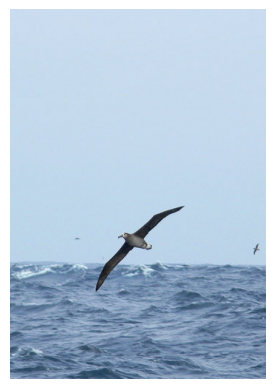

In [1]:
from CQA.datasets import GenericDataset
import torch


test = GenericDataset(ds_name='cub', split = 'test')
   

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 2. Display the image
plt.imshow(test[0][0])

# 3. Remove axes (optional but common for images)
plt.axis('off')

# 4. Show the plot
plt.show()

In [5]:
'''
Create cub_preprocess.txt list of concepts given the original one in cub.txt

'''
from loguru import logger
import os



cub_original_concepts_path = "/mnt/cimec-storage6/users/nicola.debole/home/CQA/data/concepts/cub/cub.txt"

indexes = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, 
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, 
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, 
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

concepts = {}
with open(cub_original_concepts_path) as f:
    lines = f.read().split("\n")
    print(lines)
    for line in lines:
        try:
            index, desc = line.split(" ")
            concepts[index] = desc
            print(index, desc)
        except:
            logger.warning(f"Line not processed: '{line}'")
            pass

attr_id_to_name = dict()
with open(cub_original_concepts_path, 'r') as f:
        for line in f:
            idx, name = line.strip().split(' ')
            attr_id_to_name[int(idx) - 1] = name
    
print(attr_id_to_name)




2025-06-20 11:42:24.168 | WARNING  | __main__:<module>:27 - Line not processed: ''


['1 has_bill_shape::curved_(up_or_down)', '2 has_bill_shape::dagger', '3 has_bill_shape::hooked', '4 has_bill_shape::needle', '5 has_bill_shape::hooked_seabird', '6 has_bill_shape::spatulate', '7 has_bill_shape::all-purpose', '8 has_bill_shape::cone', '9 has_bill_shape::specialized', '10 has_wing_color::blue', '11 has_wing_color::brown', '12 has_wing_color::iridescent', '13 has_wing_color::purple', '14 has_wing_color::rufous', '15 has_wing_color::grey', '16 has_wing_color::yellow', '17 has_wing_color::olive', '18 has_wing_color::green', '19 has_wing_color::pink', '20 has_wing_color::orange', '21 has_wing_color::black', '22 has_wing_color::white', '23 has_wing_color::red', '24 has_wing_color::buff', '25 has_upperparts_color::blue', '26 has_upperparts_color::brown', '27 has_upperparts_color::iridescent', '28 has_upperparts_color::purple', '29 has_upperparts_color::rufous', '30 has_upperparts_color::grey', '31 has_upperparts_color::yellow', '32 has_upperparts_color::olive', '33 has_upperp

In [ ]:
cub_original_concepts_path = "/mnt/cimec-storage6/users/nicola.debole/home/CQA/data/concepts/cub/cub.txt"

# This are the Koh provided indexes
indexes = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, 
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, 
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, 
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]
# This is the Koh function to extract concepts ids to name
# This will create a dict of 
# {'0': "Name of the Concept 1", '1': "Name of the Concept 2", ...}
attr_id_to_name = dict()
with open(cub_original_concepts_path, 'r') as f:
        for line in f:
            idx, name = line.strip().split(' ')
            attr_id_to_name[int(idx) - 1] = name
# Print the first concept name
print(attr_id_to_name[indexes[0]])
# The first concept used is "1" and the name will be "has_bill_shape::dagger" which is the 2nd concept in the 312 total concept list


# Now we construct our own concept set in this way
# Basically for each line we will have
# {'1': "Name of the Concept 1", '2' "Name of the Concept 2", ...}
concepts = {}
with open(cub_original_concepts_path) as f:
    lines = f.read().split("\n")
    for line in lines:
        try:
            index, desc = line.split(" ")
            concepts[index] = desc
        except:
            pass
        
# And use a this indexing
corr_idx = [i+1 for i in indexes]
preprocessed_concepts = []
for idx in corr_idx:
    desc = concepts[str(idx)]
    preprocessed_concepts.append(desc)

# Let's print the first concept
print(preprocessed_concepts[0])
# The first concept used is "2" and the name will be "has_bill_shape::dagger" which is the 2nd concept in the 312 total concept list



has_bill_shape::dagger
has_bill_shape::dagger
